## Устанавливаем и подключаем библиотеки

In [92]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from pathlib import Path

## 1. Настройки

In [93]:
# Изображение подшипника
IMAGE_PATH = 'data/raw/4.png'

# Каталог для сохранения результатов
RESULTS_DIR = Path('results')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ШАГ 2. Загрузка изображения и оценка исходных параметров

In [94]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise FileNotFoundError(
        'Изображение не найдено'
    )

height, width = img.shape[:2]

channels = (
    1
    if img.ndim == 2
    else img.shape[2]
)

print('Параметры исходного изображения')
print('--------------------------------')
print('Ширина:', width)
print('Высота:', height)
print('Количество каналов:', channels)
print('Тип данных:', img.dtype)

cv2.imwrite(
    str(RESULTS_DIR / '01_original.png'),
    img
)

Параметры исходного изображения
--------------------------------
Ширина: 1636
Высота: 2000
Количество каналов: 3
Тип данных: uint8


True

# Шаг 3. Преобразование цветового пространства и анализ гистограммы

1. ПРЕОБРАЗОВАНИЕ В ОТТЕНКИ СЕРОГО

In [95]:
gray = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2GRAY
)

cv2.imwrite(
    str(RESULTS_DIR / '02_gray.png'),
    gray
)


True

2. ПРЕОБРАЗОВАНИЕ В HSV

In [96]:
hsv = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2HSV
)

hue, saturation, value = cv2.split(hsv)

cv2.imwrite(
    str(RESULTS_DIR / '03_hue.png'),
    hue
)

cv2.imwrite(
    str(RESULTS_DIR / '04_saturation.png'),
    saturation
)

cv2.imwrite(
    str(RESULTS_DIR / '05_value.png'),
    value
)

True

3. ОТОБРАЖЕНИЕ ЦВЕТОВЫХ ПРЕОБРАЗОВАНИЙ

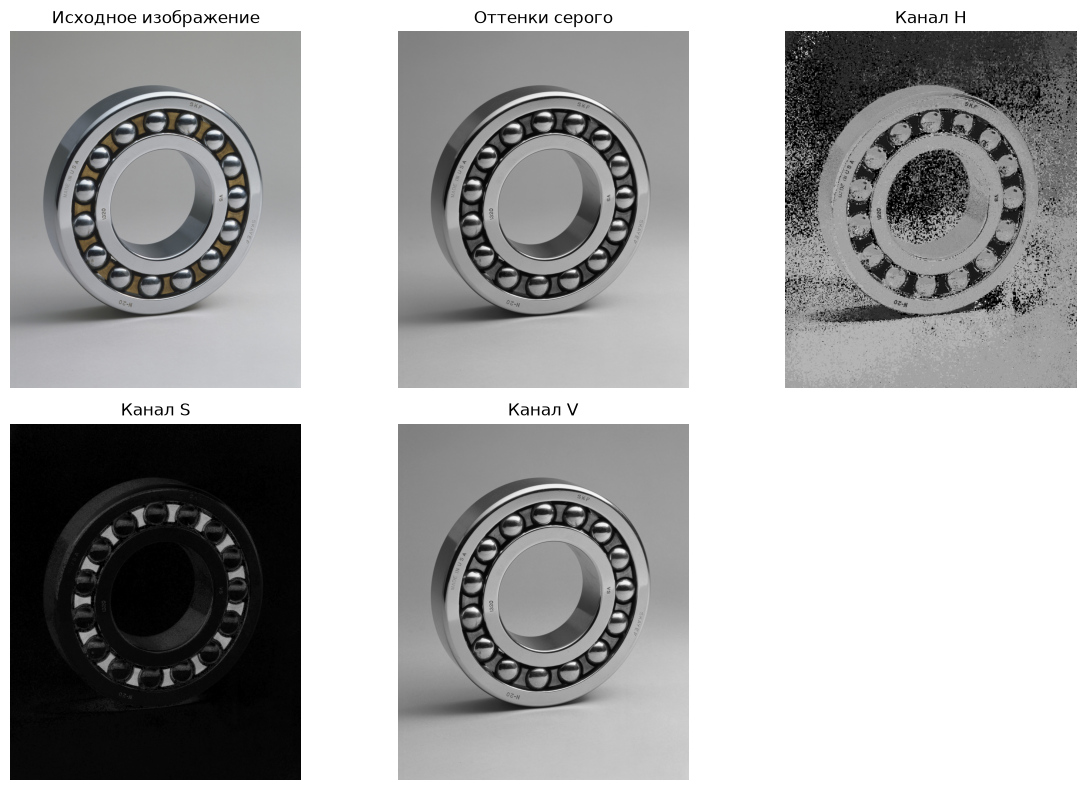

In [97]:
img_rgb = cv2.cvtColor(
    img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img_rgb)
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title('Оттенки серого')
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(hue, cmap='gray')
plt.title('Канал H')
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(saturation, cmap='gray')
plt.title('Канал S')
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(value, cmap='gray')
plt.title('Канал V')
plt.axis('off')

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / '06_color_spaces.png',
    dpi=150
)

plt.show()

4. ГИСТОГРАММА ЯРКОСТИ

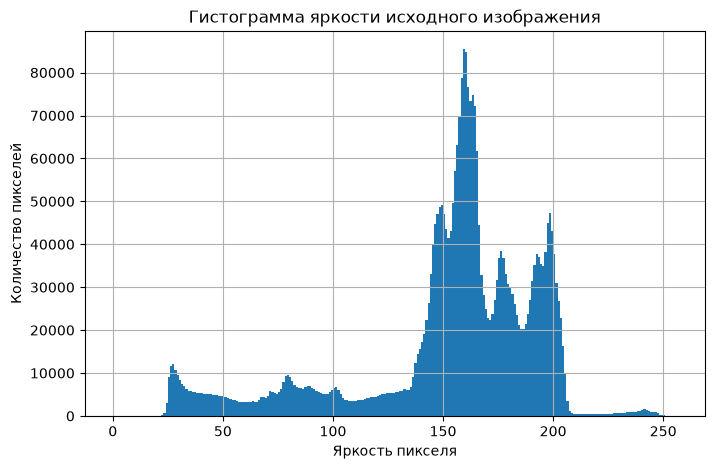

In [98]:
plt.figure(figsize=(8, 5))

plt.hist(
    gray.ravel(),
    bins=256,
    range=(0, 256)
)

plt.xlabel('Яркость пикселя')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма яркости исходного изображения')
plt.grid(True)

plt.savefig(
    RESULTS_DIR / '07_histogram.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

# Шаг 4. Коррекция яркости и контраста

4.1 ЛИНЕЙНАЯ КОРРЕКЦИЯ ЯРКОСТИ И КОНТРАСТА

In [99]:
alpha = 1.1 # коэффициент контраста
beta = 10 # изменение яркости

linear = cv2.convertScaleAbs(
    img,
    alpha=alpha,
    beta=beta
)

cv2.imwrite(
    str(RESULTS_DIR / '08_linear.png'),
    linear
)

True

4.2 ГАММА-КОРРЕКЦИЯ

In [100]:
gamma = 0.9

gamma_table = np.array([
    ((i / 255.0) ** gamma) * 255
    for i in range(256)
]).astype('uint8')

gamma_img = cv2.LUT(
    img,
    gamma_table
)

cv2.imwrite(
    str(RESULTS_DIR / '09_gamma.png'),
    gamma_img
)

True

4.3 CLAHE

In [101]:
def apply_clahe(image):
    """
    Локальное повышение контрастности CLAHE.
    Обработка выполняется по каналу яркости L
    цветового пространства LAB.
    """

    lab = cv2.cvtColor(
        image,
        cv2.COLOR_BGR2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l_new = clahe.apply(l)

    lab_new = cv2.merge(
        (l_new, a, b)
    )

    result = cv2.cvtColor(
        lab_new,
        cv2.COLOR_LAB2BGR
    )

    return result


In [102]:
clahe_img = apply_clahe(img)

cv2.imwrite(
    str(RESULTS_DIR / '10_clahe.png'),
    clahe_img
)

True

4.4 СРАВНЕНИЕ КОРРЕКЦИИ ЯРКОСТИ И КОНТРАСТА

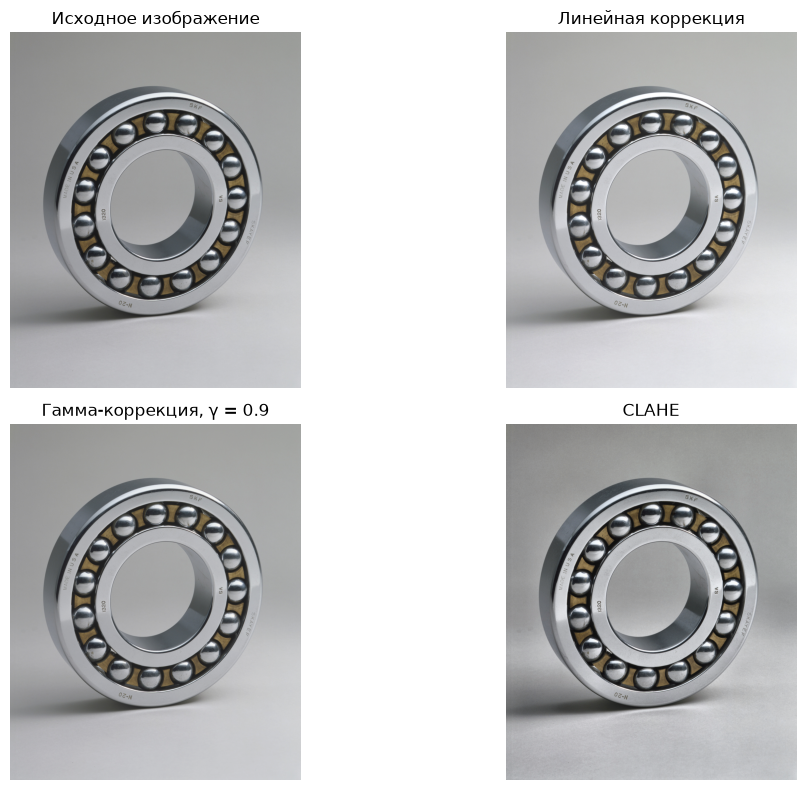

In [103]:
linear_rgb = cv2.cvtColor(
    linear,
    cv2.COLOR_BGR2RGB
)

gamma_rgb = cv2.cvtColor(
    gamma_img,
    cv2.COLOR_BGR2RGB
)

clahe_rgb = cv2.cvtColor(
    clahe_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(img_rgb)
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(linear_rgb)
plt.title('Линейная коррекция')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(gamma_rgb)
plt.title(f'Гамма-коррекция, γ = {gamma}')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(clahe_rgb)
plt.title('CLAHE')
plt.axis('off')

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / '11_correction_comparison.png',
    dpi=150
)

plt.show()


# Шаг 5. Сравнение методов фильтрации

Добавляем шумы

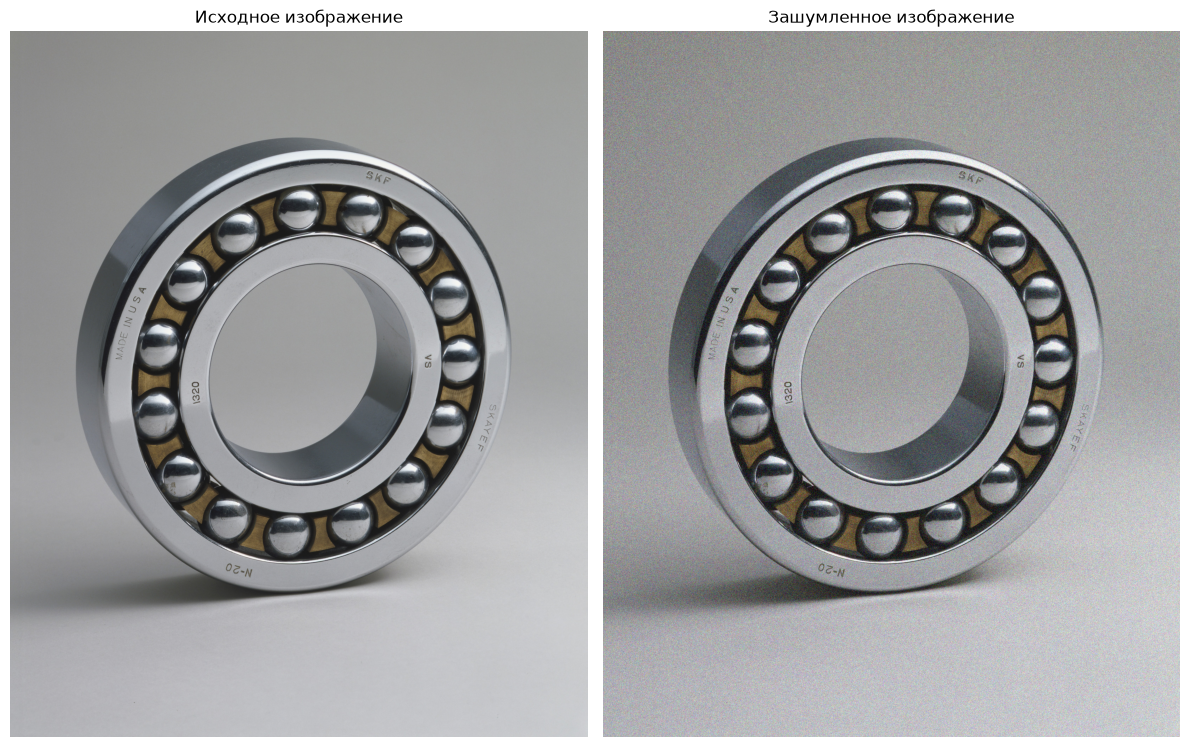

In [104]:
noise = np.random.normal(0, 25, img.shape)

# Добавляем шум
noisy = img.astype(np.float32) + noise

# Ограничиваем значения диапазоном 0..255
noisy = np.clip(noisy, 0, 255).astype(np.uint8)

noisy_rgb = cv2.cvtColor(
    noisy,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_rgb, cmap='gray')
plt.title('Зашумленное изображение')
plt.axis('off')

plt.tight_layout()

5.1 ГАУССОВ ФИЛЬТР

In [105]:
gaussian = cv2.GaussianBlur(
    noisy,
    (5, 5),
    0
)

cv2.imwrite(
    str(RESULTS_DIR / '12_gaussian.png'),
    gaussian
)


True

5.2 МЕДИАННЫЙ ФИЛЬТР

In [106]:
median = cv2.medianBlur(
    noisy,
    5
)

cv2.imwrite(
    str(RESULTS_DIR / '13_median.png'),
    median
)

True

5.3 БИЛАТЕРАЛЬНЫЙ ФИЛЬТР

In [107]:
bilateral = cv2.bilateralFilter(
    noisy,
    9,
    75,
    75
)

cv2.imwrite(
    str(RESULTS_DIR / '14_bilateral.png'),
    bilateral
)

True

5.4 СРАВНЕНИЕ РЕЗУЛЬТАТОВ ФИЛЬТРАЦИИ

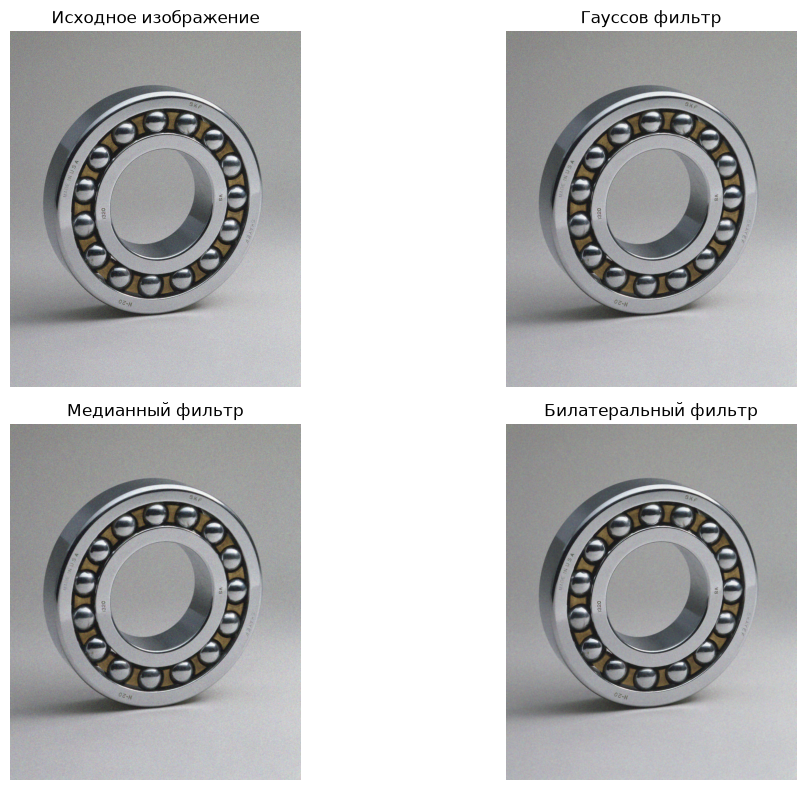

In [108]:
gaussian_rgb = cv2.cvtColor(
    gaussian,
    cv2.COLOR_BGR2RGB
)

median_rgb = cv2.cvtColor(
    median,
    cv2.COLOR_BGR2RGB
)

bilateral_rgb = cv2.cvtColor(
    bilateral,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
plt.imshow(noisy_rgb)
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(gaussian_rgb)
plt.title('Гауссов фильтр')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(median_rgb)
plt.title('Медианный фильтр')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(bilateral_rgb)
plt.title('Билатеральный фильтр')
plt.axis('off')

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / '15_filter_comparison.png',
    dpi=150
)

plt.show()

5.5 ИЗМЕРЕНИЕ ВРЕМЕНИ ФИЛЬТРАЦИИ

In [109]:
def mean_time_ms(func, image, repeats=50):
    """
    Определяет среднее время выполнения операции
    в миллисекундах.
    """

    times = []

    for _ in range(repeats):

        start = time.perf_counter()

        func(image)

        end = time.perf_counter()

        times.append(
            (end - start) * 1000
        )

    return np.mean(times)

In [110]:
gaussian_time = mean_time_ms(
    lambda x:
    cv2.GaussianBlur(
        x,
        (5, 5),
        0
    ),
    img
)

median_time = mean_time_ms(
    lambda x:
    cv2.medianBlur(
        x,
        5
    ),
    img
)

bilateral_time = mean_time_ms(
    lambda x:
    cv2.bilateralFilter(
        x,
        9,
        75,
        75
    ),
    img
)


print()
print('Среднее время обработки')
print('--------------------------------')

print(
    'Гауссов фильтр:',
    round(gaussian_time, 3),
    'мс'
)

print(
    'Медианный фильтр:',
    round(median_time, 3),
    'мс'
)

print(
    'Билатеральный фильтр:',
    round(bilateral_time, 3),
    'мс'
)


Среднее время обработки
--------------------------------
Гауссов фильтр: 3.528 мс
Медианный фильтр: 9.093 мс
Билатеральный фильтр: 40.895 мс


# Шаг 6. Изменение размера и подготовка изображения к дальнейшим работам

6.1 ИЗМЕНЕНИЕ РАЗМЕРА ДО 640x640

In [111]:
def resize_with_padding(image, size=640, value=114):
    """
    Изменяет размер изображения до size x size
    с сохранением исходного соотношения сторон.
    Свободные области заполняются постоянным значением.
    """

    h, w = image.shape[:2]

    scale = min(size / w, size / h)

    new_w = int(w * scale)
    new_h = int(h * scale)

    resized = cv2.resize(
        image,
        (new_w, new_h),
        interpolation=cv2.INTER_AREA
    )

    top = (size - new_h) // 2
    bottom = size - new_h - top

    left = (size - new_w) // 2
    right = size - new_w - left

    result = cv2.copyMakeBorder(
        resized,
        top,
        bottom,
        left,
        right,
        cv2.BORDER_CONSTANT,
        value=(value, value, value)
    )

    return result

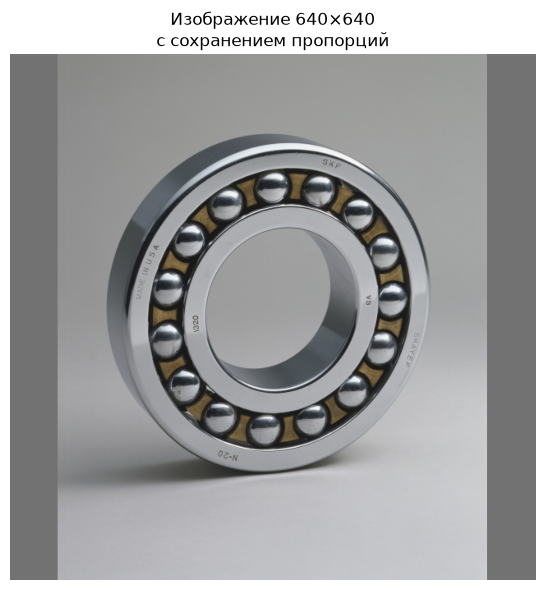

In [112]:
prepared = resize_with_padding(
    img,
    size=640,
    value=114
)

cv2.imwrite(
    str(RESULTS_DIR / '16_prepared_640.png'),
    prepared
)

prepared_rgb = cv2.cvtColor(
    prepared,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(6, 6))

plt.imshow(prepared_rgb)

plt.title(
    'Изображение 640×640\n'
    'с сохранением пропорций'
)

plt.axis('off')

plt.tight_layout()

plt.savefig(
    RESULTS_DIR / '17_resize_result.png',
    dpi=150
)

plt.show()

# Шаг 8. Формирование итогового варианта предобработки

In [113]:
# 1. Локальная коррекция контраста
final_img = apply_clahe(img)

# 2. Медианная фильтрация
final_img = cv2.medianBlur(
    final_img,
    5
)

# 3. Размер 640x640 с сохранением пропорций
final_img = resize_with_padding(
    final_img,
    640,
    114
)

cv2.imwrite(
    str(RESULTS_DIR / '18_final_processed.png'),
    final_img
)

True

СРАВНЕНИЕ ИСХОДНОГО И ИТОГОВОГО ИЗОБРАЖЕНИЯ

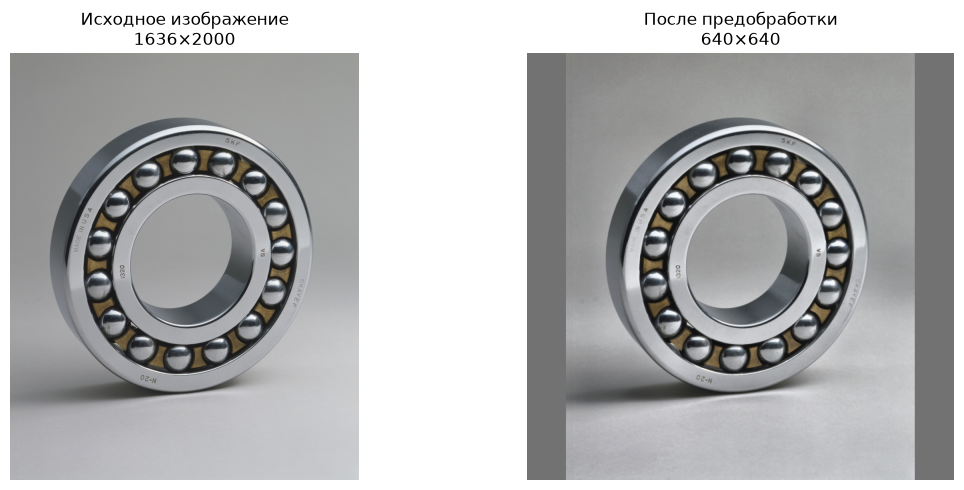

In [114]:
final_rgb = cv2.cvtColor(
    final_img,
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)

plt.imshow(img_rgb)

plt.title(
    'Исходное изображение\n'
    f'{width}×{height}'
)

plt.axis('off')


plt.subplot(1, 2, 2)

plt.imshow(final_rgb)

plt.title(
    'После предобработки\n'
    '640×640'
)

plt.axis('off')


plt.tight_layout()

plt.savefig(
    RESULTS_DIR / '19_before_after.png',
    dpi=150
)

plt.show()

ВЫВОД ИНФОРМАЦИИ

In [115]:
print()
print('=========================================')
print('ОБРАБОТКА ЗАВЕРШЕНА')
print('=========================================')

print(
    'Исходное разрешение:',
    width,
    'x',
    height
)

print(
    'Итоговое разрешение:',
    final_img.shape[1],
    'x',
    final_img.shape[0]
)

print(
    'Результаты сохранены в каталоге:',
    RESULTS_DIR
)


ОБРАБОТКА ЗАВЕРШЕНА
Исходное разрешение: 1636 x 2000
Итоговое разрешение: 640 x 640
Результаты сохранены в каталоге: results
